# Exploratory Data Analysis

### Import libaries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette="pastel")

First, let's read the CSV file prepared in the previous step.

In [2]:
df = pd.read_csv('data/animal_dataset_processed.csv')

In [3]:
df.head()

,Animal,Height (cm),Weight (kg),Color,Lifespan (years),Diet,Habitat,Predators,Average Speed (km/h),Countries Found,Conservation Status,Family,Gestation Period (days),Social Structure,Offspring per Birth
0,Aardvark,117.5,52.5,Grey,25.0,Carnivore,"Savannas, Grasslands","Lions, Hyenas",40.0,Africa,Least Concern,Orycteropodidae,225.0,Solitary,1.0
1,Aardwolf,45.0,11.0,Yellow-brown,11.0,Carnivore,"Grasslands, Savannas","Lions, Leopards",27.0,Eastern and Southern Africa,Least Concern,Hyaenidae,90.0,Solitary,3.5
2,African Elephant,290.0,4350.0,Grey,65.0,Herbivore,"Savannas, Forests","Lions, Hyenas",25.0,Africa,Vulnerable,Elephantidae,650.0,Herd-based,1.0
3,African Lion,95.0,185.0,Tan,12.0,Carnivore,"Grasslands, Savannas","Hyenas, Crocodiles",58.0,Africa,Vulnerable,Felidae,101.5,Group-based,3.0
4,African Wild Dog,77.5,27.0,Multicolored,11.0,Carnivore,Savannas,"Lions, Hyenas",56.0,Sub-Saharan Africa,Endangered,Canidae,70.0,Group-based,11.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Animal                   187 non-null    object 
 1   Height (cm)              187 non-null    float64
 2   Weight (kg)              187 non-null    float64
 3   Color                    187 non-null    object 
 4   Lifespan (years)         187 non-null    float64
 5   Diet                     187 non-null    object 
 6   Habitat                  187 non-null    object 
 7   Predators                187 non-null    object 
 8   Average Speed (km/h)     187 non-null    float64
 9   Countries Found          187 non-null    object 
 10  Conservation Status      187 non-null    object 
 11  Family                   187 non-null    object 
 12  Gestation Period (days)  187 non-null    float64
 13  Social Structure         187 non-null    object 
 14  Offspring per Birth      1

In [5]:
df.describe()

,Height (cm),Weight (kg),Lifespan (years),Average Speed (km/h),Gestation Period (days),Offspring per Birth
count,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000
mean,175.828877,1889.816746,22.933983,31.377995,134.829259,1182.791444
std,373.586782,15409.975050,18.961394,22.355671,129.028395,14636.520588
min,4.500000,0.006000,0.071429,0.025000,0.071429,1.000000
25%,40.000000,3.325000,11.500000,14.000000,37.000000,1.000000
50%,78.500000,31.500000,17.500000,30.000000,90.000000,2.500000
75%,150.000000,180.000000,27.500000,45.750000,207.500000,15.750000
max,3200.000000,200000.000000,125.000000,120.000000,650.000000,200000.000000


## Data visualization

### A Quick Overview of Numeric Column Data

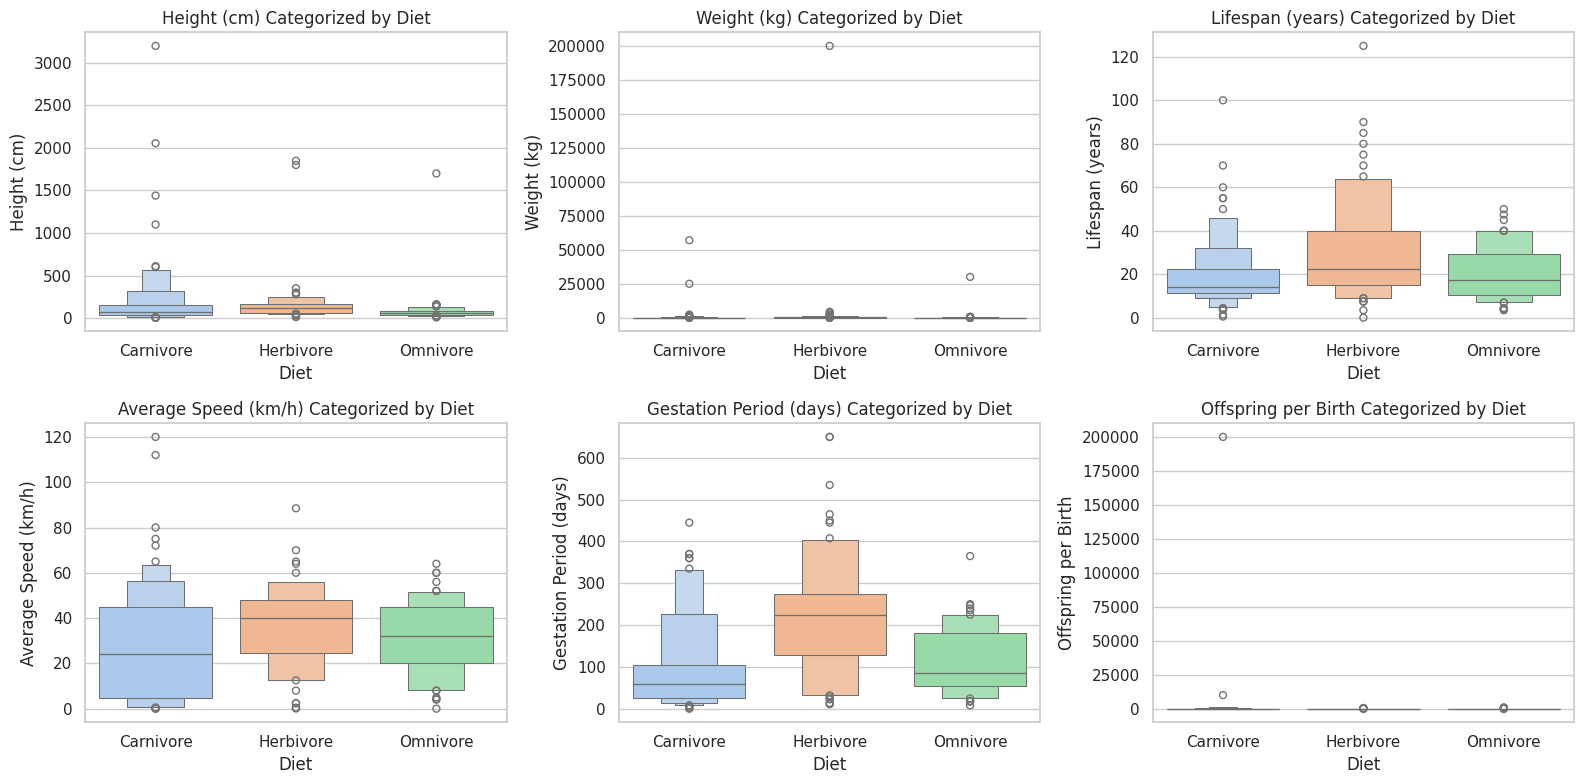

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax = ax.flatten()

columns = ['Height (cm)', 'Weight (kg)', 'Lifespan (years)', 'Average Speed (km/h)', 'Gestation Period (days)', 'Offspring per Birth']
for i, col in enumerate(columns):
    sns.boxenplot(data=df, x='Diet', y=col, hue='Diet', ax=ax[i])
    ax[i].set_title(f'{col} Categorized by Diet')

plt.tight_layout()
plt.show()

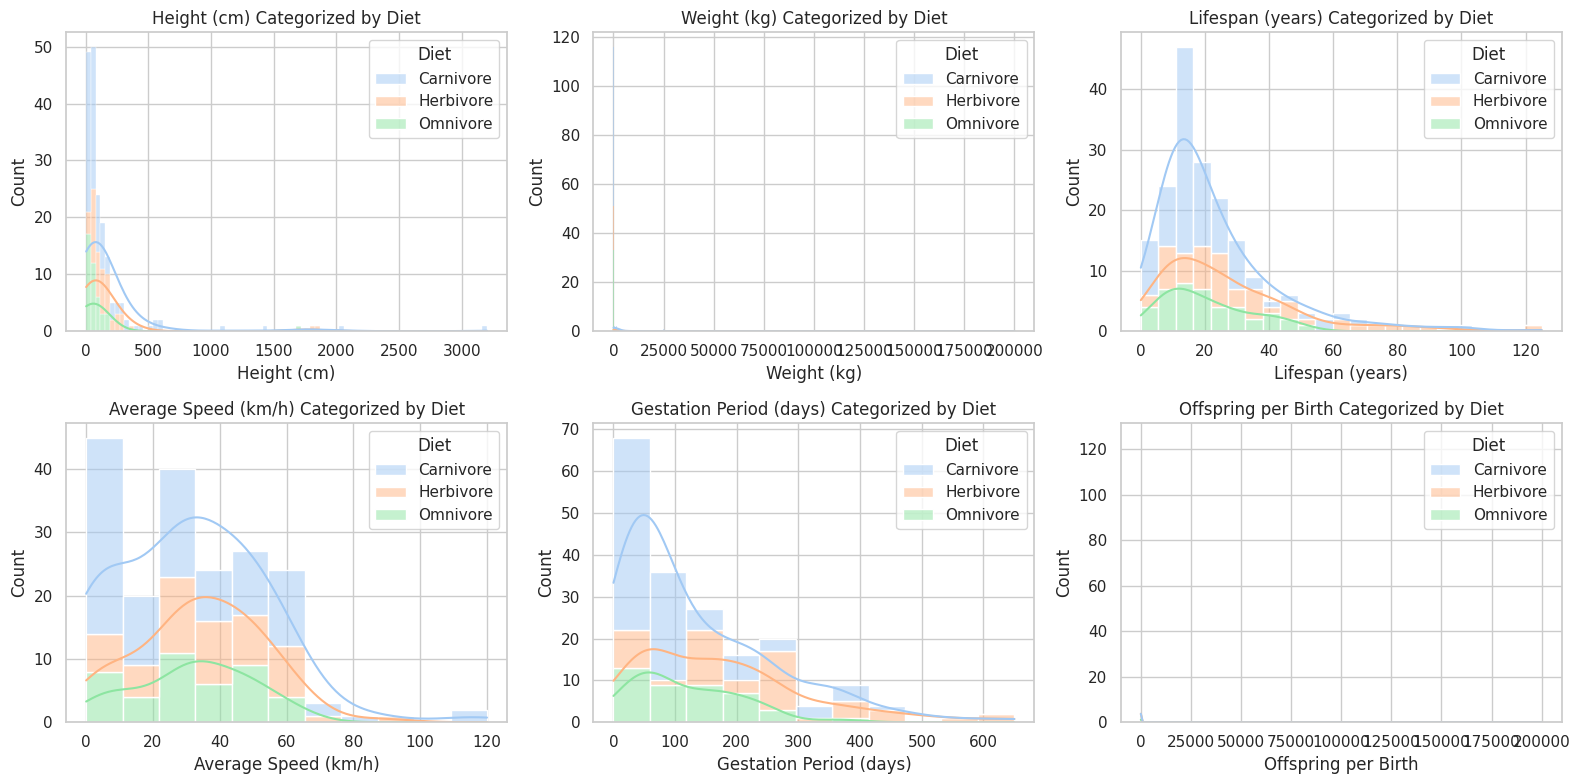

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax = ax.flatten()

columns = ['Height (cm)', 'Weight (kg)', 'Lifespan (years)', 'Average Speed (km/h)', 'Gestation Period (days)', 'Offspring per Birth']
for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, kde=True, hue='Diet', multiple='stack', ax=ax[i])
    ax[i].set_title(f'{col} Categorized by Diet')

plt.tight_layout()
plt.show()

Observing the data, we can identify some outliers especially in the 'Weight (kg)' and 'Offspring per Birth' columns. After a thorough analysis, we should address these outliers appropriately.

### Visualization of animal heights in the dataset

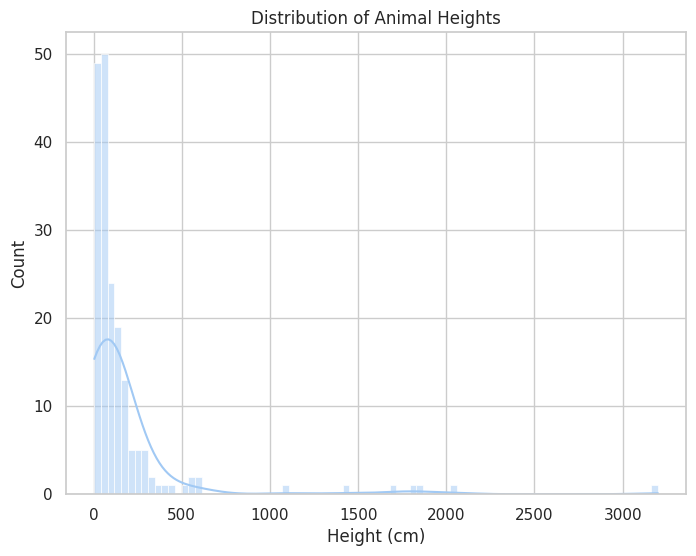

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(df, x='Height (cm)', kde=True)
plt.title('Distribution of Animal Heights')
plt.show()

Ninety-five percent of the animals are under 5 meters in length. The following diagram illustrates the distribution of these animals categorized by their diet.

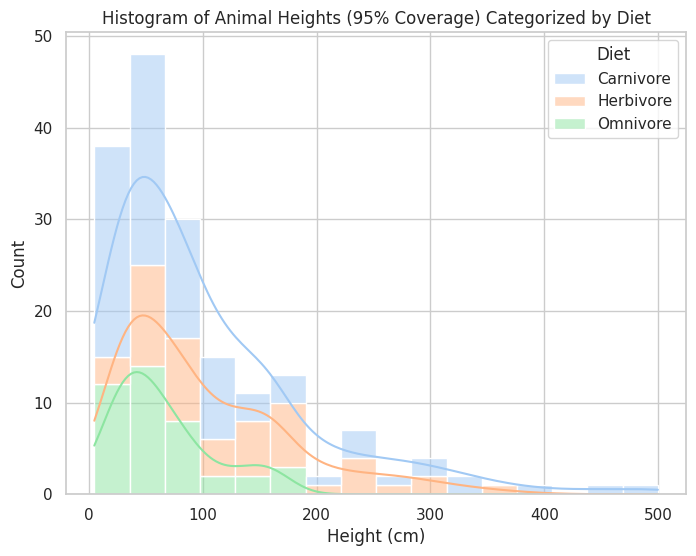

In [9]:
plt.figure(figsize=(8, 6))
data = df[df['Height (cm)'] < df['Height (cm)'].quantile(0.95)]
sns.histplot(data, x='Height (cm)', kde=True, hue='Diet', multiple='stack')
plt.title('Histogram of Animal Heights (95% Coverage) Categorized by Diet')
plt.show()

### Visualization of animal Weights in the dataset

Ninety percent of the animals weigh less than 1.5 tons. The following diagram illustrates the distribution of these animals, categorized by their diet.

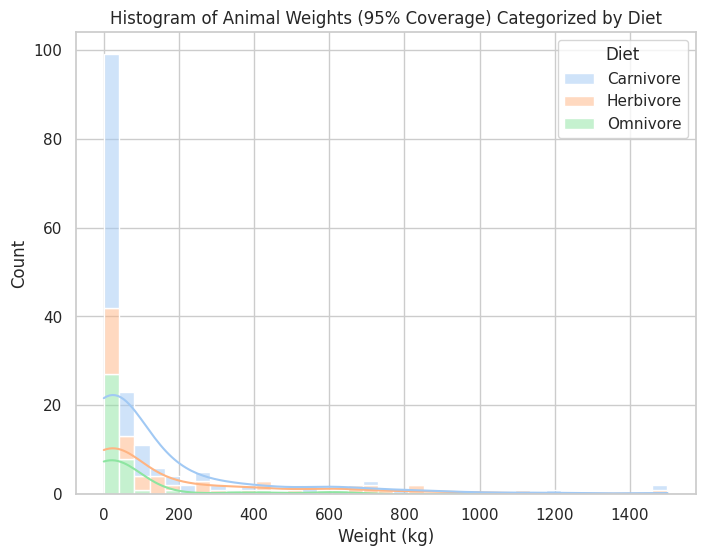

In [10]:
plt.figure(figsize=(8, 6))
data = df[df['Weight (kg)'] < df['Weight (kg)'].quantile(0.95)]
sns.histplot(data, x='Weight (kg)', kde=True, hue='Diet', multiple='stack')
plt.title('Histogram of Animal Weights (95% Coverage) Categorized by Diet')
plt.show()

### Visualization of animal Weights and Heights in the dataset

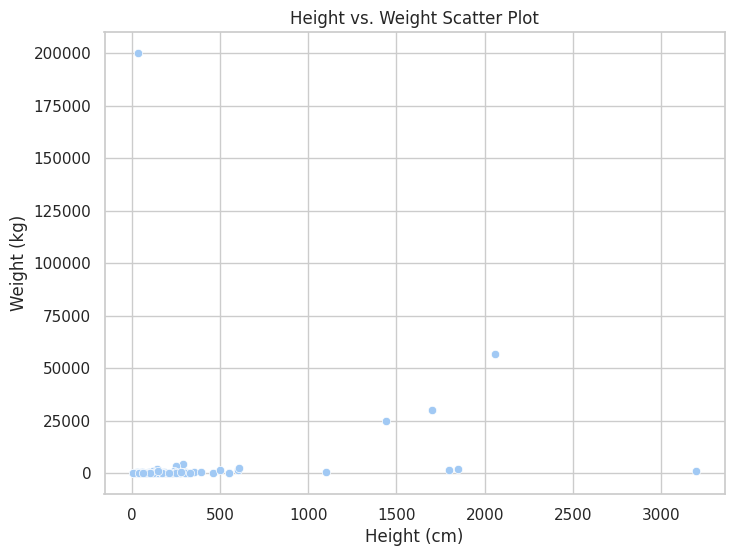

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(df, x='Height (cm)', y='Weight (kg)')
plt.title('Height vs. Weight Scatter Plot')
plt.show()

Height and weight scatter plot (95% coverage), categorized by diet type.

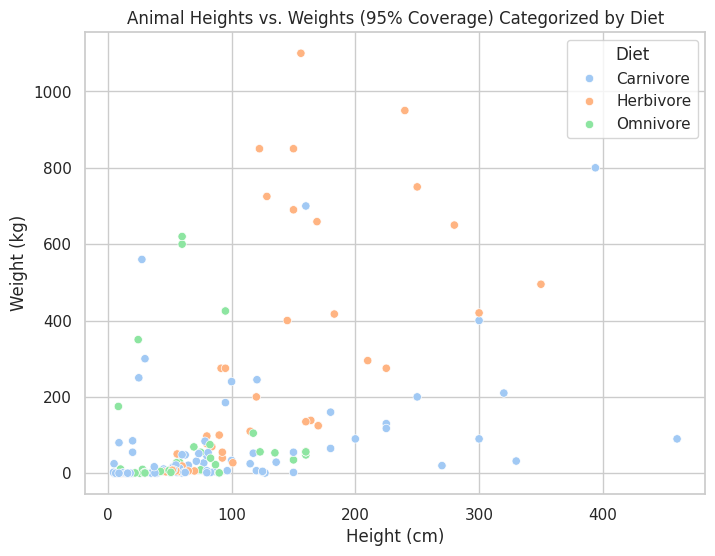

In [12]:
plt.figure(figsize=(8, 6))
data = df[(df['Height (cm)'] < 500) & (df['Weight (kg)'] < 1500)]
sns.scatterplot(data, x='Height (cm)', y='Weight (kg)', hue='Diet')
plt.title('Animal Heights vs. Weights (95% Coverage) Categorized by Diet')
plt.show()

### Visualization of animal Average Speed in the dataset

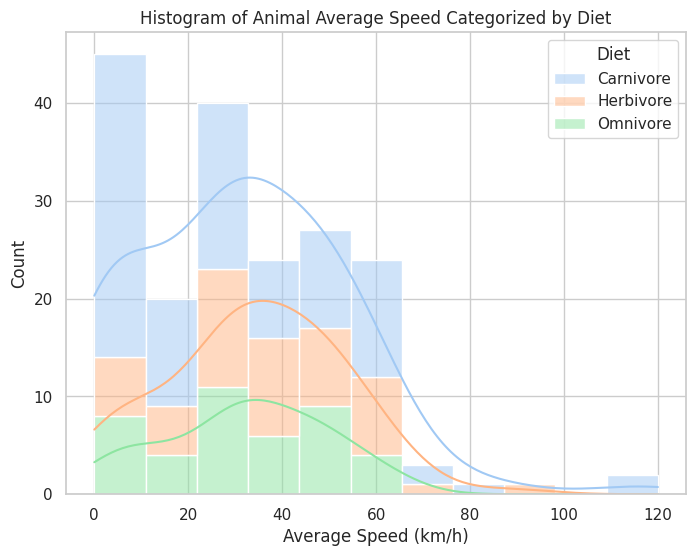

In [13]:
plt.figure(figsize=(8, 6))
sns.histplot(df, x='Average Speed (km/h)', kde=True, hue='Diet', multiple='stack')
plt.title('Histogram of Animal Average Speed Categorized by Diet')
plt.show()

### Visualization of animal Lifespan in the dataset

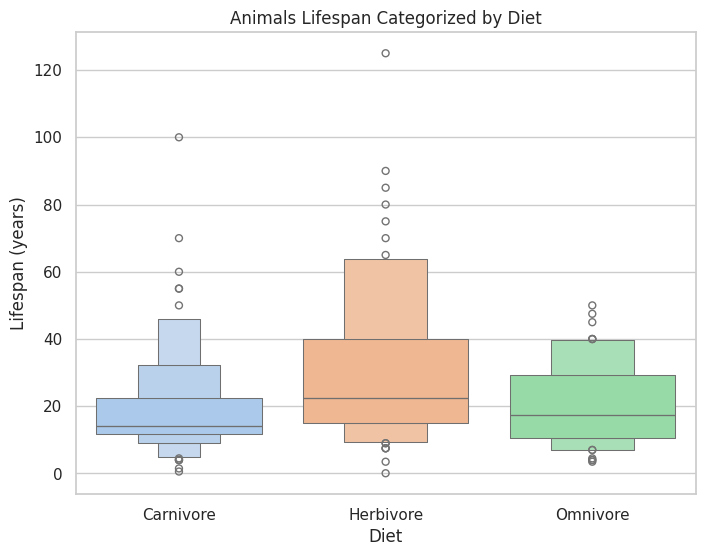

In [14]:
plt.figure(figsize=(8, 6))
plt.title('Animals Lifespan Categorized by Diet')
sns.boxenplot(df, x='Diet', y='Lifespan (years)', hue='Diet')
plt.show()

### Visualization of animal Offspring per Birth in the dataset

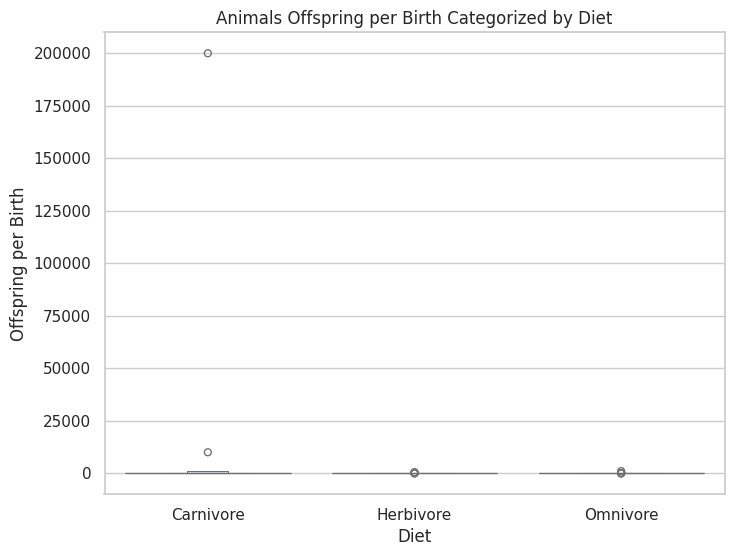

In [15]:
plt.figure(figsize=(8, 6))
plt.title('Animals Offspring per Birth Categorized by Diet')
sns.boxenplot(df, x='Diet', y='Offspring per Birth', hue='Diet')
plt.show()

Ninety percent of the animals Offspring per Birth is less than 80. The following diagram illustrates the distribution of these animals, categorized by their diet.

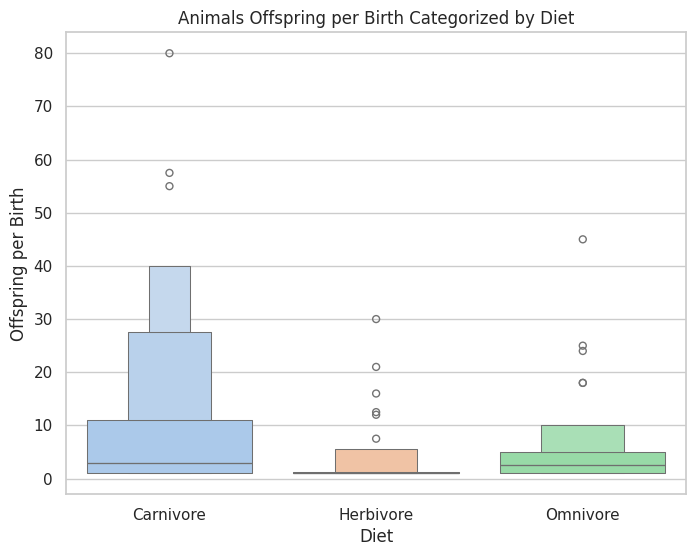

In [16]:
data = df[df['Offspring per Birth'] < df['Offspring per Birth'].quantile(0.9)]
plt.figure(figsize=(8, 6))
plt.title('Animals Offspring per Birth Categorized by Diet')
sns.boxenplot(data, x='Diet', y='Offspring per Birth', hue='Diet')
plt.show()

### Visualization of animal Gestation Period in the dataset

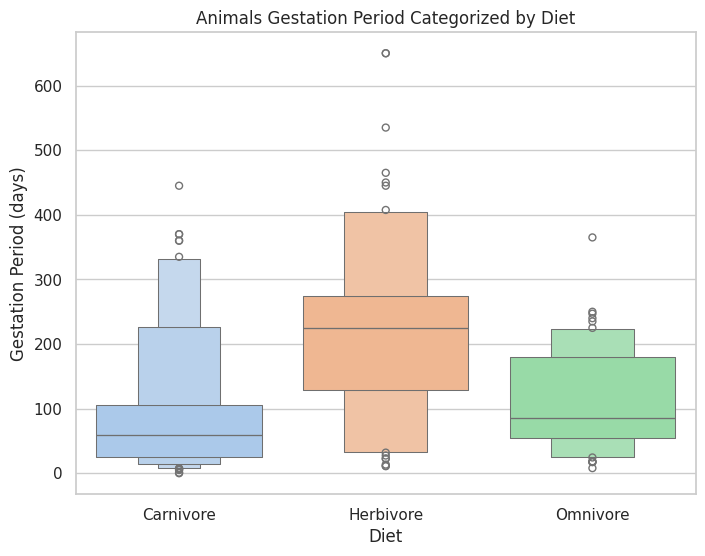

In [17]:
plt.figure(figsize=(8, 6))
plt.title('Animals Gestation Period Categorized by Diet')
sns.boxenplot(df, x='Diet', y='Gestation Period (days)', hue='Diet')
plt.show()

### A Quick Overview of Categorical Column Data

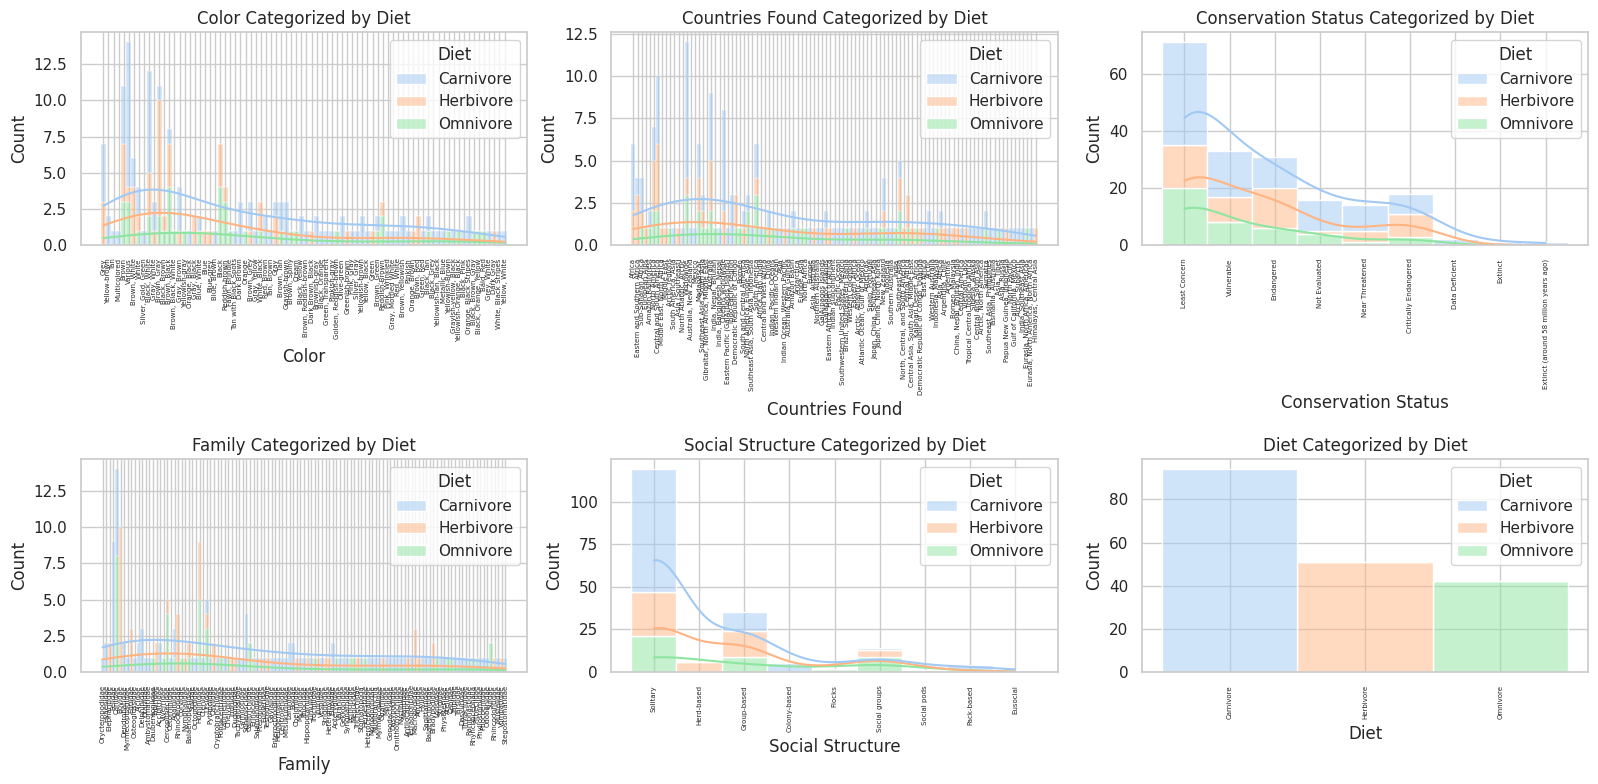

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax = ax.flatten()

columns = ['Color', 'Countries Found', 'Conservation Status', 'Family', 'Social Structure', 'Diet']
for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, kde=True, hue='Diet', multiple='stack', ax=ax[i])
    ax[i].set_title(f'{col} Categorized by Diet')
    ax[i].tick_params(axis='x', rotation=90, labelsize=5)

plt.tight_layout()
plt.show()

### Visualization of animal Color in the dataset

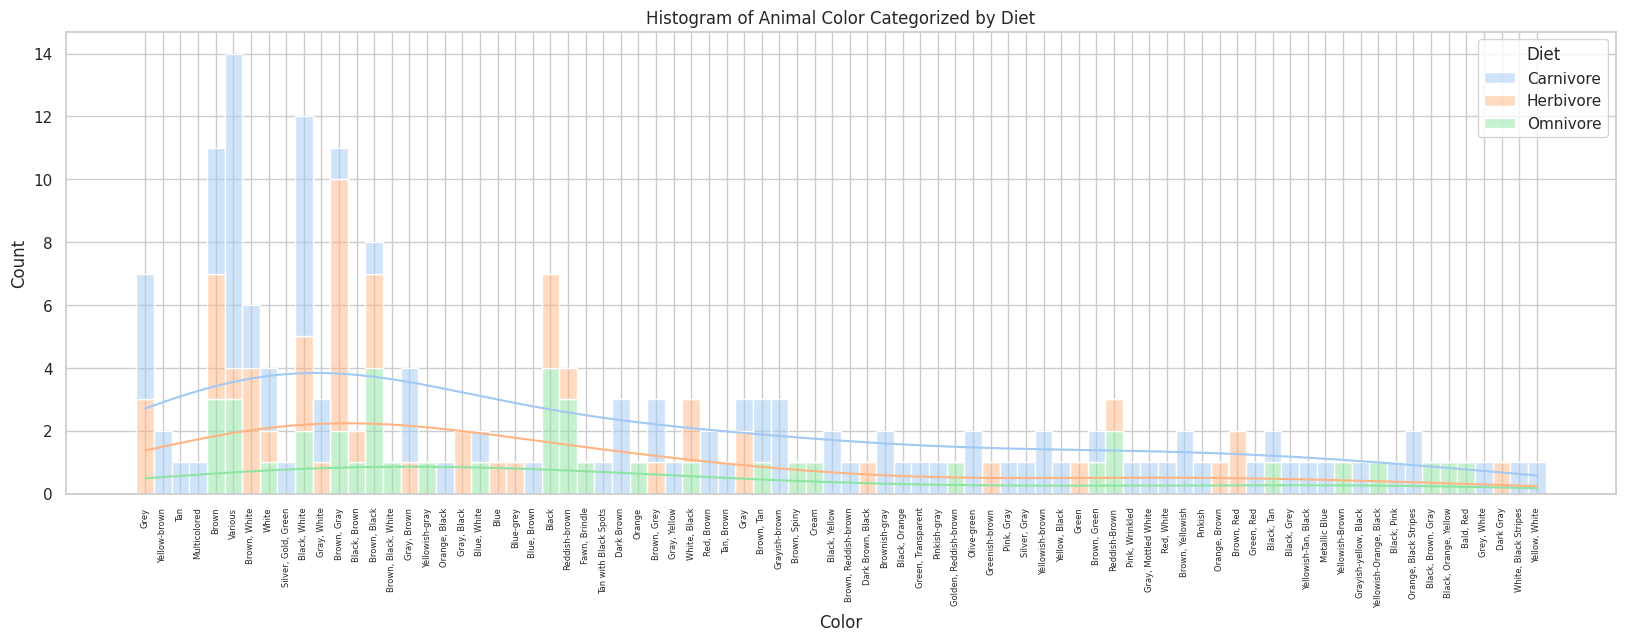

In [19]:
plt.figure(figsize=(20, 6))
sns.histplot(df, x='Color', kde=True, hue='Diet', multiple='stack')
plt.title('Histogram of Animal Color Categorized by Diet')
plt.tick_params(axis='x', rotation=90, labelsize=6)
plt.show()

### Visualization of animal Family in the dataset

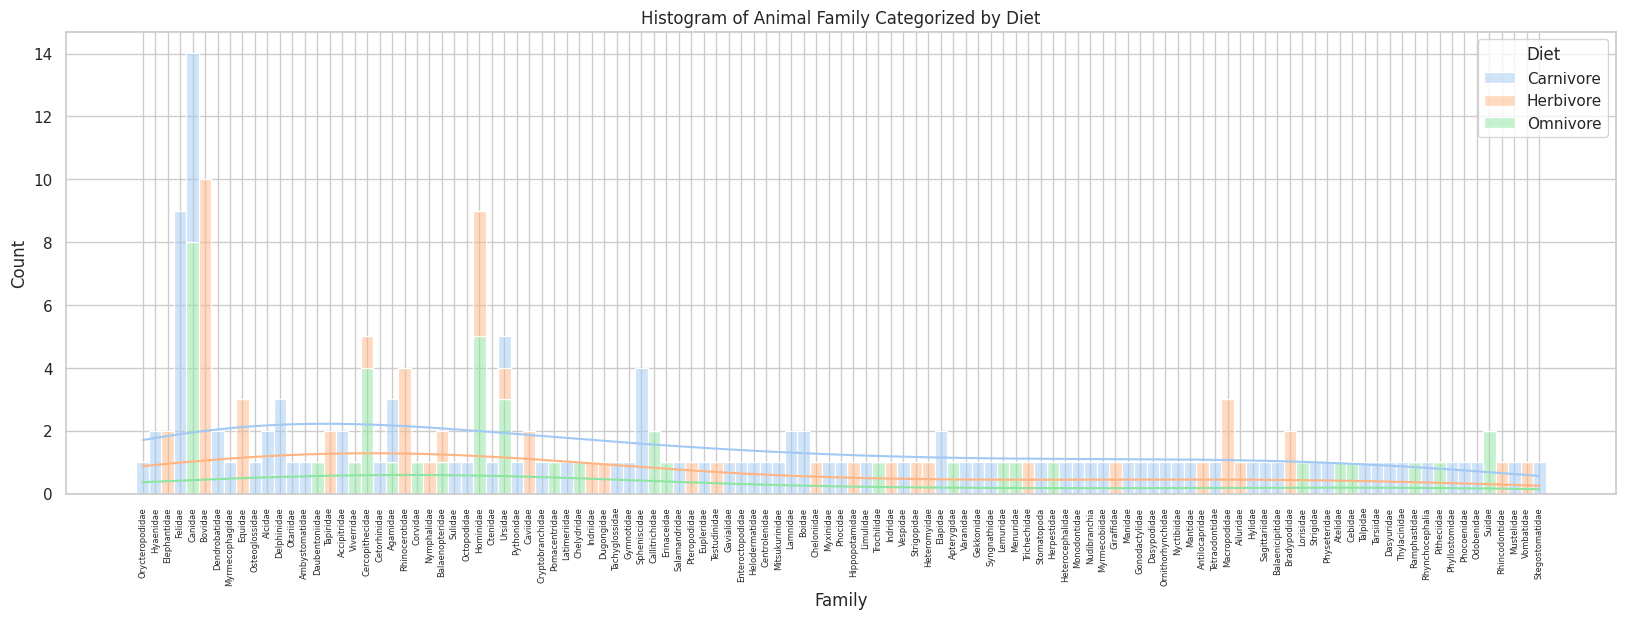

In [20]:
plt.figure(figsize=(20, 6))
sns.histplot(df, x='Family', kde=True, hue='Diet', multiple='stack')
plt.title('Histogram of Animal Family Categorized by Diet')
plt.tick_params(axis='x', rotation=90, labelsize=6)
plt.show()

### Visualization of animal Conservation Status in the dataset

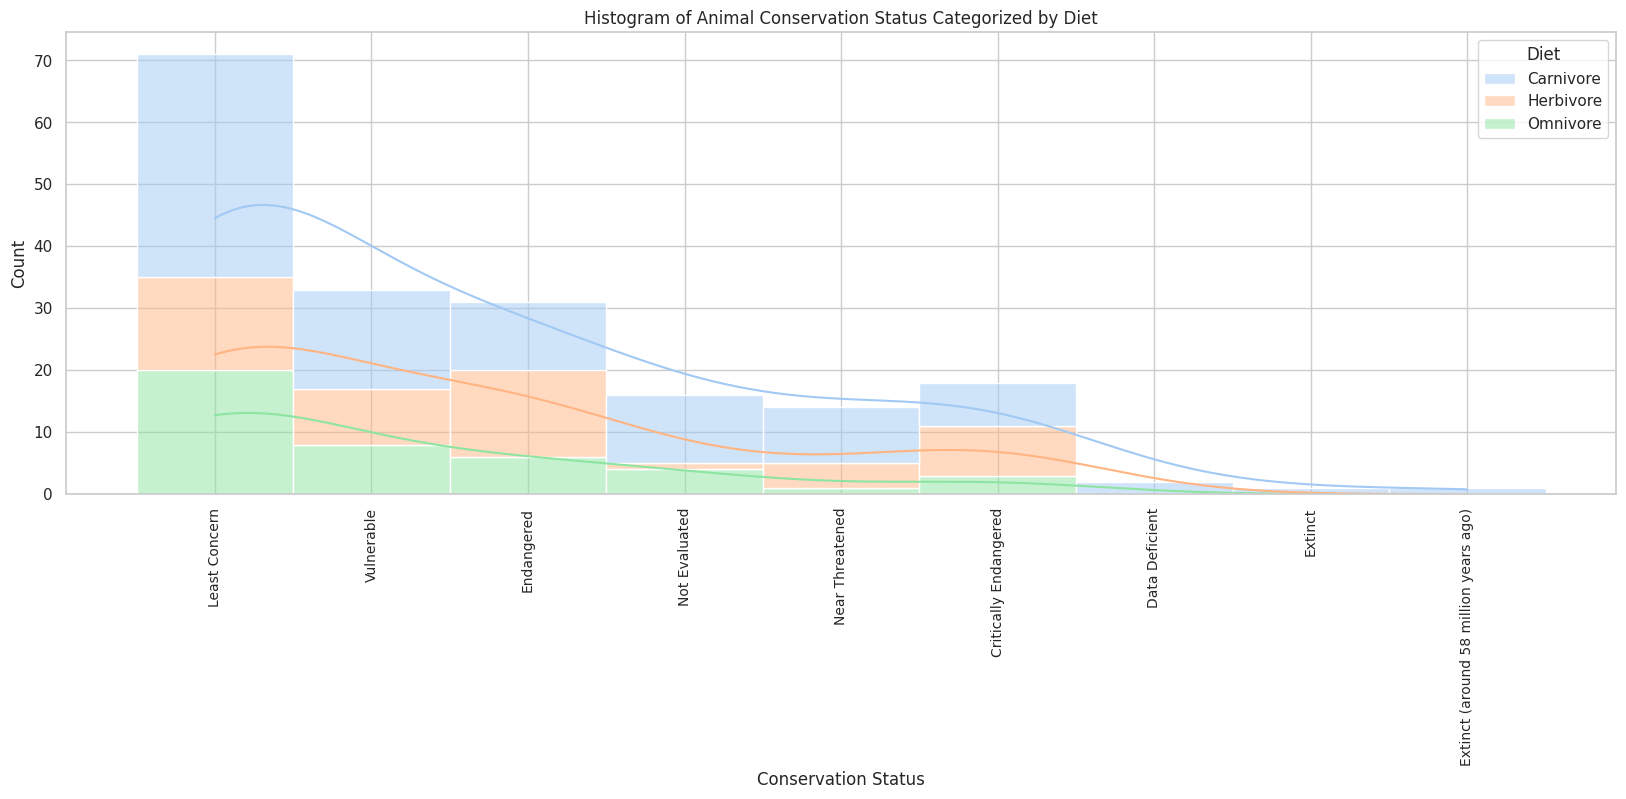

In [21]:
plt.figure(figsize=(20, 6))
sns.histplot(df, x='Conservation Status', kde=True, hue='Diet', multiple='stack')
plt.title('Histogram of Animal Conservation Status Categorized by Diet')
plt.tick_params(axis='x', rotation=90, labelsize=10)
plt.show()

### Visualization of animal Social Structure in the dataset

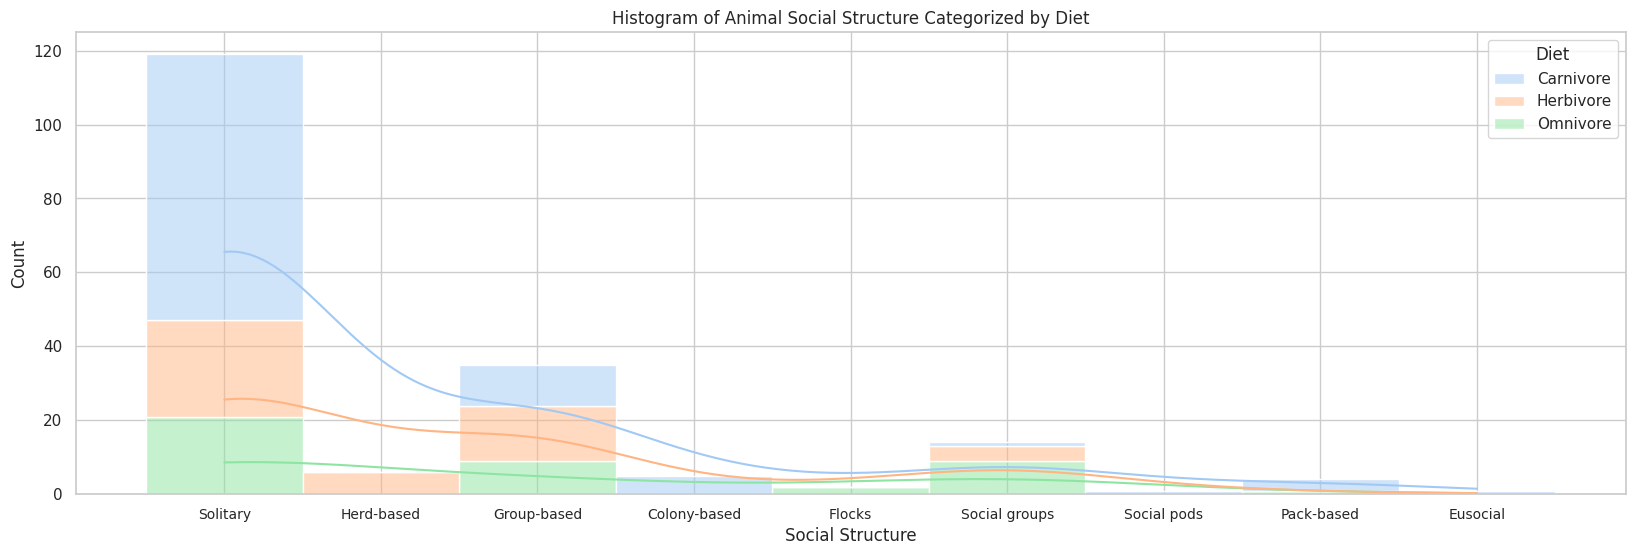

In [22]:
plt.figure(figsize=(20, 6))
sns.histplot(df, x='Social Structure', kde=True, hue='Diet', multiple='stack')
plt.title('Histogram of Animal Social Structure Categorized by Diet')
plt.tick_params(axis='x', labelsize=10)
plt.show()

### Visualization of animal Countries Found in the dataset

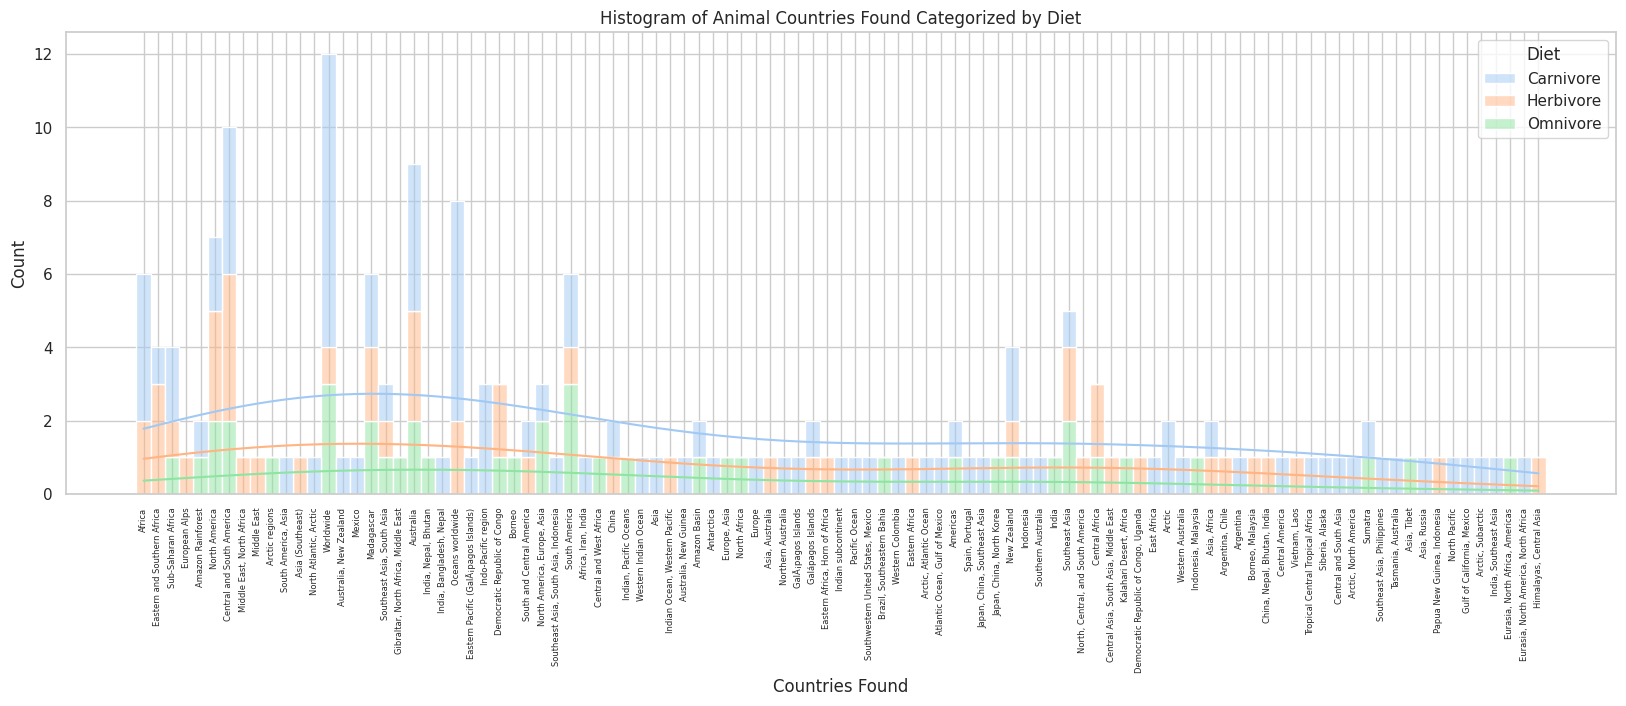

In [23]:
plt.figure(figsize=(20, 6))
sns.histplot(df, x='Countries Found', kde=True, hue='Diet', multiple='stack')
plt.title('Histogram of Animal Countries Found Categorized by Diet')
plt.tick_params(axis='x', rotation=90, labelsize=6)
plt.show()

### Visualization of animal Predators in the dataset

In [24]:
split_data = df['Predators'].str.split(', ', expand=True).stack()

unique_predators = split_data.unique()
one_hot_df = pd.get_dummies(split_data).groupby(level=0).sum()
one_hot_df = one_hot_df.reindex(columns=unique_predators, fill_value=0)

data = df.join(one_hot_df)

An interesting fact is that humans are the top predators of most animal species.

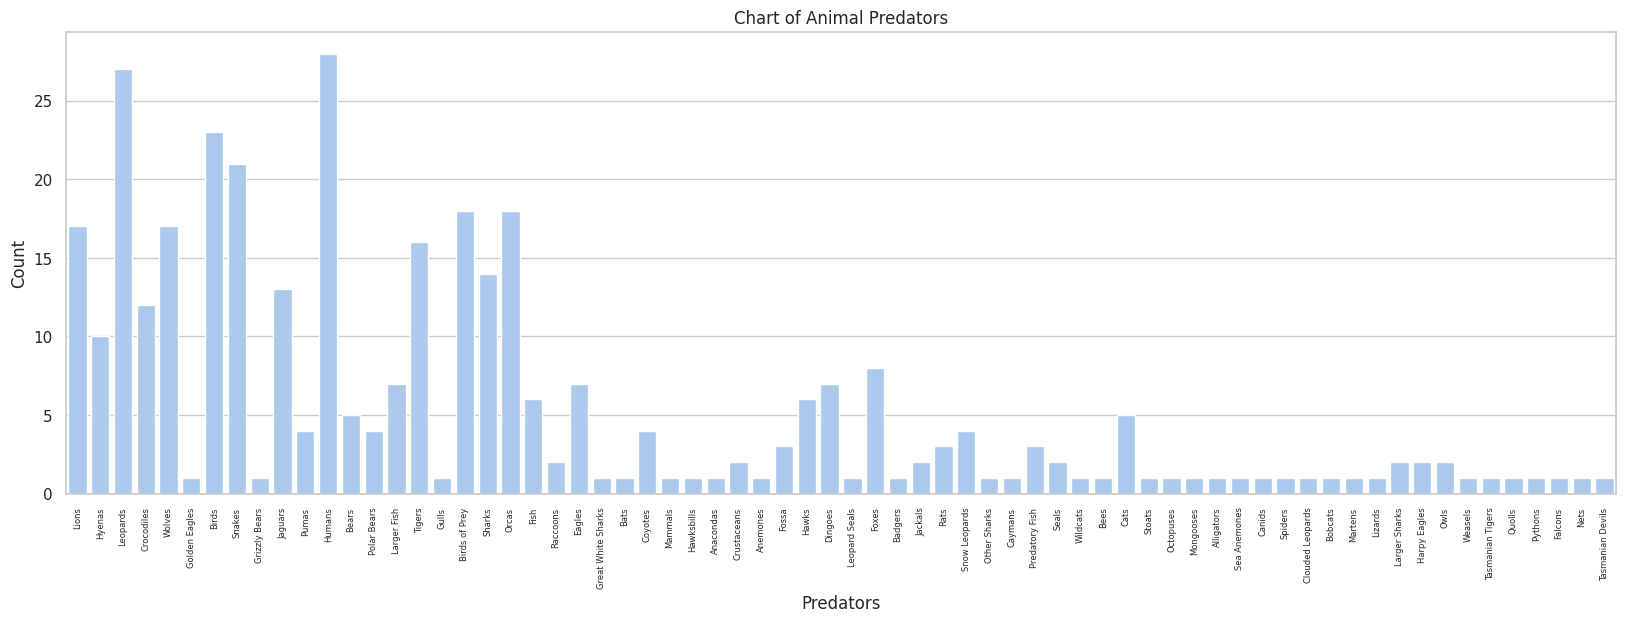

In [25]:
plt.figure(figsize=(20, 6))
column_sums = data[unique_predators].sum()
sns.barplot(x=column_sums.index, y=column_sums.values)
plt.title('Chart of Animal Predators')
plt.xlabel('Predators')
plt.ylabel('Count')
plt.tick_params(axis='x', rotation=90, labelsize=6)
plt.show()

### Visualization of animal Habitat in the dataset

In [26]:
split_data = df['Habitat'].str.split(', ', expand=True).stack()

unique_habitat = split_data.unique()
one_hot_df = pd.get_dummies(split_data).groupby(level=0).sum()
one_hot_df = one_hot_df.reindex(columns=unique_habitat, fill_value=0)

data = df.join(one_hot_df)

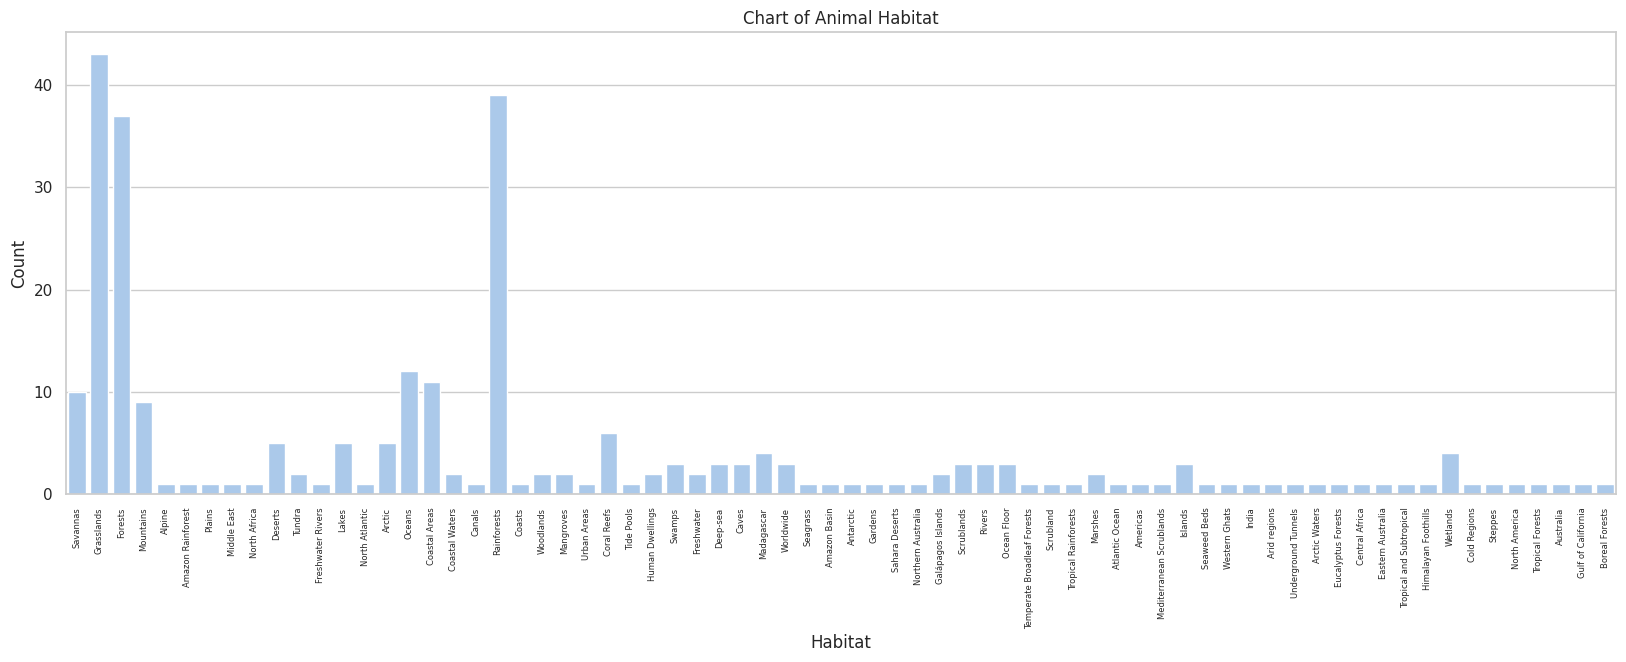

In [27]:
plt.figure(figsize=(20, 6))
column_sums = data[unique_habitat].sum()
sns.barplot(x=column_sums.index, y=column_sums.values)
plt.title('Chart of Animal Habitat')
plt.xlabel('Habitat')
plt.ylabel('Count')
plt.tick_params(axis='x', rotation=90, labelsize=6)
plt.show()

## Descriptive Statistics

### Numeric data correlation

<Axes: >

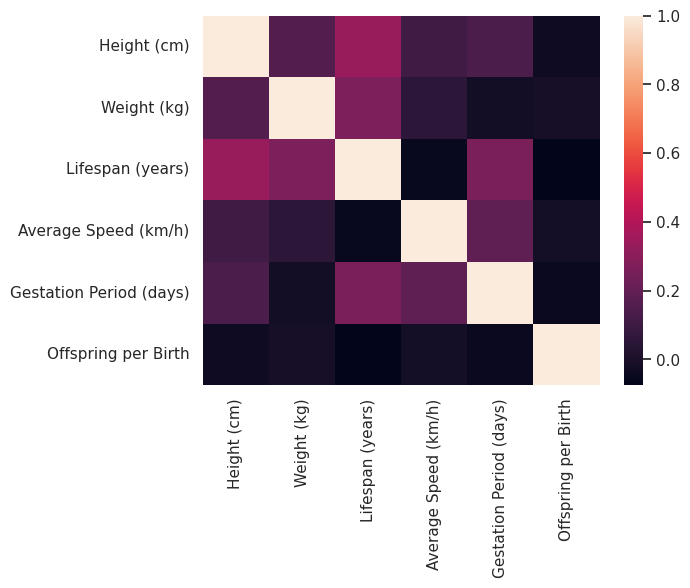

In [28]:
columns = ['Height (cm)', 'Weight (kg)', 'Lifespan (years)', 'Average Speed (km/h)', 'Gestation Period (days)', 'Offspring per Birth']
corr_df = df[columns]
corr_df = corr_df.corr()
sns.heatmap(corr_df)

### Chi2 Test

In [29]:
from scipy.stats import chi2_contingency

def chi2_test(df, feature1, feature2):
    contingency_table = pd.crosstab(df[feature1], df[feature2])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.sum().sum()
    cramer_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

    print(f"Chi-Square Statistic: {chi2}")
    print(f"P-value: {p}")
    print(f"Cramér's V: {cramer_v}")

Performing a Chi-squared test between the target and each feature. A value closer to 1 indicates a higher correlation.

In [30]:
for col in df.columns:
    print(f'Chi2 test between Diet(Target) and {col}:')
    chi2_test(df, 'Diet', col)
    print()

Chi2 test between Diet(Target) and Animal:
Chi-Square Statistic: 374.0
P-value: 0.4611146471985472
Cramér's V: 1.0

Chi2 test between Diet(Target) and Height (cm):
Chi-Square Statistic: 228.81936423505573
P-value: 0.509589098540692
Cramér's V: 0.7821869865396085

Chi2 test between Diet(Target) and Weight (kg):
Chi-Square Statistic: 313.2088399189463
P-value: 0.2611244026443496
Cramér's V: 0.9151266531071691

Chi2 test between Diet(Target) and Color:
Chi-Square Statistic: 184.4975545182612
P-value: 0.07330635160262973
Cramér's V: 0.7023595726550352

Chi2 test between Diet(Target) and Lifespan (years):
Chi-Square Statistic: 152.5786024175082
P-value: 0.03170421858205067
Cramér's V: 0.6387207352097788

Chi2 test between Diet(Target) and Diet:
Chi-Square Statistic: 374.0
P-value: 1.1510381903759662e-79
Cramér's V: 1.0

Chi2 test between Diet(Target) and Habitat:
Chi-Square Statistic: 191.2222988131423
P-value: 0.2694191674346567
Cramér's V: 0.715045151734558

Chi2 test between Diet(Target)